<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_4_MLR_Ames_Part4_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 4
## Hyperparameter Tuning with Grid Search

Author: Brad Sheese

**Recap:**
*   In Part 3 we introduced Regularization (Ridge, Lasso, ElasticNet). We learned that by penalizing large coefficients, we can stabilize our models and prevent overfitting.
*   However, in Part 3, we arbitrarily picked the penalty strength ($\alpha=1.0$ or $\alpha=0.01$). We guessed.

**This Notebook:**
*   We stop guessing. We will use Cross-Validation and Grid Search to scientifically find the optimal hyperparameters for our models.
*   We will visualize the Bias-Variance Tradeoff to understand why a specific alpha value performs best.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()
df.loc[df['Garage Yr Blt'] > 2010, 'Garage Yr Blt'] = 2010

# Helper function
def safe_drop(df: pd.DataFrame, drop_list: list[str]) -> pd.DataFrame:
    existing_cols_to_drop = [col for col in drop_list if col in df.columns]
    if existing_cols_to_drop:
        df = df.drop(existing_cols_to_drop, axis=1)
    return df

# --- Compressed Cleaning Logic (Matches Part 3) ---

# 1. Create Flags
df['garage_attached'] = np.where(df['Garage Type'] == 'Attchd', 1, 0)
df['garage_unfinished'] = np.where(df['Garage Finish'] != 'Unf', 1, 0)

# 2. Consolidated Drop List
drop_list = [
    'Order', 'PID', 'Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val',
    'Alley', 'Fence', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2', 'Fireplace Qu', 'Neighborhood',
    'MS Subclass', 'Mo Sold', 'Kitchen Qual', 'Exter Qual', 'Heating QC',
    'Garage Qual', 'Garage Cond', 'Garage Type', 'Garage Finish', 'Street',
    'Land Contour', 'Utilities', 'Land Slope', 'Condition 1', 'Condition 2',
    'Roof Matl', 'Exter Cond', 'Heating', 'Central Air', 'Electrical',
    'Functional', 'Paved Drive', 'Sale Type', 'Exterior 1st', 'Exterior 2nd',
    'Mas Vnr Area'
]
df = safe_drop(df, drop_list)

# 3. Collapse High Cardinality Categoricals
for col in df.select_dtypes(include=['object']).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.50:
    top_value = (df[col].value_counts(normalize=True, dropna=False).index[0])
    df[col + '_' + top_value] = np.where(df[col] == top_value, 1, 0)
    df = safe_drop(df, [col])

# 4. Handle Foundation & Types
df.loc[~df['Foundation'].isin(['PConc', 'CBlock']), 'Foundation'] = 'Other'

for col in df.select_dtypes('object').columns:
  df[col] = df[col].astype('category')

for col in df.columns:
  if df[col].value_counts().shape[0] == 2:
    df[col] = df[col].astype('bool')

# 5. Drop Highly Uniform Numerics
for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.90:
    df = safe_drop(df, [col])

# 6. Booleanize Sparse Numerics
for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.80:
    if len(df[col].unique()) > 2:
      df[col] = np.where(df[col] > 0, 1, 0)
    df[col] = df[col].astype('boolean')

# 7. Impute Missing Values
num_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

# 8. One-Hot Encoding
df = pd.get_dummies(df, columns=df.select_dtypes(include='category').columns, drop_first=True)

print(f"Final dataframe shape: {df.shape}")

Final dataframe shape: (2925, 39)


In [2]:
from sklearn.model_selection import train_test_split

# Define features and target
# Remember: We log-transform the target to handle skewness
X = df.drop(columns=['SalePrice'])
y = df['SalePrice'].map(np.log)

# Split the data (80% Train, 20% Test)
# We will perform Cross-Validation ONLY on the Training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Why Tune Hyperparameters?

In regularized regression (Ridge, Lasso, ElasticNet), the **Alpha ($\alpha$)** parameter controls the strength of the penalty.

*   **Too Low ($\alpha \approx 0$)**: The model behaves like OLS. It might overfit the training data (High Variance).
*   **Too High ($\alpha \rightarrow \infty$)**: The model is penalized too heavily. Coefficients are crushed to zero. It underfits the data (High Bias).

We need to find the "Goldilocks" zone: not too hot, not too cold.

## 1. Visualizing the Bias-Variance Tradeoff (Manual Tuning)

Before automating this, let's manually loop through a list of possible alpha values for **Ridge Regression** and see how the error changes.

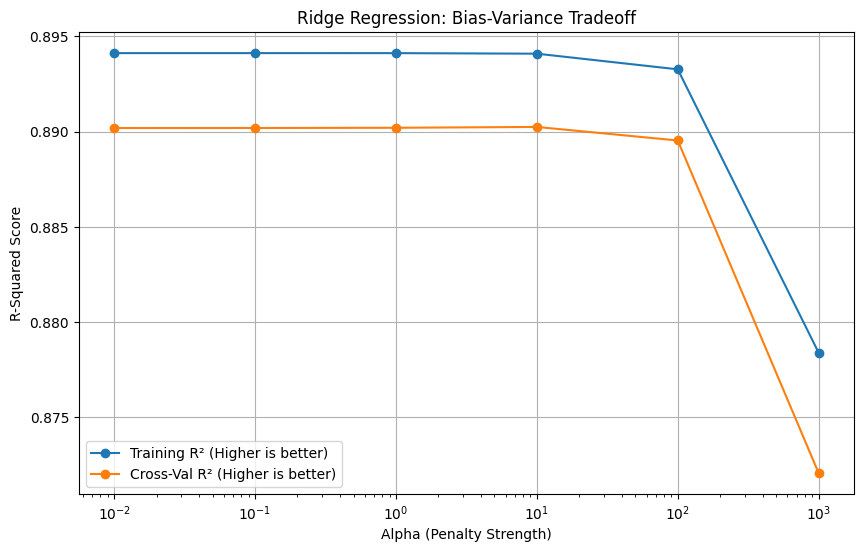

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Range of alphas to test (logarithmic scale is usually best)
alphas = [0.01, 0.1, 1, 10, 100, 1000]

cv_scores = []
train_scores = []

for alpha in alphas:
    # Create pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])

    # Cross-validation score (R-squared)
    # Note: cross_val_score returns the score for each fold
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

    # Also fit on full training set to check training score (for comparison)
    pipeline.fit(X_train, y_train)
    train_scores.append(pipeline.score(X_train, y_train))

# Plotting
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_scores, label='Training R² (Higher is better)', marker='o')
plt.semilogx(alphas, cv_scores, label='Cross-Val R² (Higher is better)', marker='o')
plt.xlabel('Alpha (Penalty Strength)')
plt.ylabel('R-Squared Score')
plt.title('Ridge Regression: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:**
*   **Low Alpha:** Training score is high, but CV score is slightly lower (potential overfitting).
*   **High Alpha:** Both scores drop significantly (underfitting - the model is too simple).
*   **The Peak:** The alpha where the CV score is maximized is our optimal hyperparameter.

## 2. Automated Tuning with GridSearchCV

Instead of writing loops manually, Scikit-Learn provides `GridSearchCV`.

It takes:
1.  **Estimator** (your model or pipeline)
2.  **Param Grid** (dictionary of parameters to test)
3.  **CV** (number of folds)

It runs every combination and finds the best one.

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def tune_model(model, param_grid, X_train, y_train):
    """
    Performs GridSearchCV to find the best hyperparameters.

    Why a Pipeline?
    We must scale the data *inside* the cross-validation loop. If we scaled the
    entire dataset beforehand, information from the validation fold would 'leak'
    into the training fold (via the mean and standard deviation). The Pipeline
    ensures that for every fold, the scaler is fit ONLY on the training data.
    """
    # 1. Create the pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # 2. Rename params for the pipeline
    # The pipeline steps are named 'scaler' and 'model'.
    # We must prefix our parameters with 'model__' so GridSearchCV knows where they go.
    pipeline_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

    # 3. Setup Grid Search
    # refit=True (default) means: "After finding the best params, fit the model ONE MORE TIME
    # on the entire X_train/y_train so it is ready to use."
    grid_search = GridSearchCV(
        pipeline,
        pipeline_param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        refit=True # this is the default, and unnecessary, but I want you to see it).
    )

    # 4. Run the Search
    grid_search.fit(X_train, y_train)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV R²:      {grid_search.best_score_:.4f}")

    # Return the fully fitted, best version of the pipeline
    return grid_search.best_estimator_

### 2A. Tuning Ridge Regression
We search for the best `alpha`.

In [5]:
ridge_params = {'alpha': [0.01, 0.1, 1, 5, 10, 20, 50, 100]}
best_ridge = tune_model(Ridge(), ridge_params, X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__alpha': 10}
Best CV R²:      0.8902


### 2B. Tuning Lasso Regression
Lasso is more sensitive to alpha. If alpha is too high, it drops ALL features.

In [6]:
lasso_params = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 1]}
best_lasso = tune_model(Lasso(max_iter=5000), lasso_params, X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__alpha': 0.001}
Best CV R²:      0.8903


### 2C. Tuning ElasticNet (2D Grid Search)
Here we search two dimensions:
1.  `alpha`: The overall penalty strength.
2.  `l1_ratio`: The mix. 0.0=Ridge, 1.0=Lasso.

GridSearchCV will try EVERY combination (Cartesian product).

In [7]:
enet_params = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
best_enet = tune_model(ElasticNet(max_iter=5000), enet_params, X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__alpha': 0.001, 'model__l1_ratio': 0.9}
Best CV R²:      0.8903


## 3. Final Evaluation on Test Set

Now that we have tuned our models on the training set, let's see which one actually performs best on the Test Set that none of the models have seen yet.

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    'Optimized Ridge': best_ridge,
    'Optimized Lasso': best_lasso,
    'Optimized ElasticNet': best_enet
}

results = []

for name, model in models.items():
    # Predict
    y_pred = model.predict(X_test)

    # Score
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Count features (non-zero coefficients)
    # Steps: Pipeline -> 'model' step -> coef_
    coefs = model.named_steps['model'].coef_
    n_features = np.sum(np.abs(coefs) > 1e-5) # Count non-zero coefs

    results.append({
        'Model': name,
        'Test R²': f"{r2:.4f}",
        'Test MSE': f"{mse:.4f}",
        'Features Kept': n_features
    })

# Create comparison table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               Model Test R² Test MSE  Features Kept
     Optimized Ridge  0.9358   0.0111             38
     Optimized Lasso  0.9352   0.0112             34
Optimized ElasticNet  0.9352   0.0112             34


## Conclusion

We have successfully moved from "guessing" to "optimizing." You will notice that the parameters used for the search in that last exercise were close to the optimal parameters we found here. I wanted to present a best case outcome in the previous exercise so I had previously conduced a grid search to find the values.

Moving forward, assumming you've got the time to run the analyses and can pay for the compute to do so, you will most likely always conduct a grid search instead of just guessing parameters.
